# Algorithmic Trading Strategy Optimization Using Genetic Algorithms

This notebook implements an end-to-end framework for evolving algorithmic trading strategies using **Real Parameter Evolution with Genetic Algorithms (GA)**.

### Key Objectives & Pipeline Architecture
1. **Dataset Loading**: Direct ingestion from raw remote repository dataset (`trading_data.csv`).
2. **Technical Indicator Computation**: Derives `SMA`, `RSI`, and `MACD` indicators.
3. **Gene Representation**: 9 numerical strategy parameters encoding indicator trigger thresholds and risk controls (`Stop-Loss` / `Take-Profit`).
4. **Event-Driven Backtesting**: Event-driven execution engine with intra-trade Stop-Loss / Take-Profit exits, computing Total Return, Sharpe Ratio, Maximum Drawdown, Win Rate, and Profit Factor.
5. **GA Optimization**: Multi-component fitness function, tournament selection, BLX-$\alpha$ crossover, bounded Gaussian mutation, and elitism preservation.
6. **Performance & Visual Evaluation**: Evaluates out-of-sample performance on a 30% held-out test split against a Buy & Hold benchmark.


In [1]:
import os
import copy
import random
import warnings
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')

print("Environment and libraries loaded successfully.")


Environment and libraries loaded successfully.


## 1. Data Ingestion & Technical Indicator Computation

We load the OHLCV market dataset directly from the raw GitHub repository URL, validate price integrity (`High >= max(Open, Close)` and `Low <= min(Open, Close)`), and compute `SMA`, `RSI`, and `MACD` indicators.


In [2]:
DATA_URL = 'https://raw.githubusercontent.com/Rakshak05/ML-CaPsule/master/Algorithmic_Trading_Strategy_Optimization_Using_Genetic_Algorithms/trading_data.csv'

def load_and_validate_data(url_or_path: str) -> pd.DataFrame:
    df = pd.read_csv(url_or_path)
    
    required_cols = ["Open", "High", "Low", "Close"]
    for col in required_cols:
        if col not in df.columns:
            raise KeyError(f"Missing required column: '{col}'")
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Volume" in df.columns:
        df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce").fillna(0)

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

    df = df.dropna(subset=required_cols).reset_index(drop=True)

    df["High"] = np.maximum(df["High"], np.maximum(df["Open"], df["Close"]))
    df["Low"] = np.minimum(df["Low"], np.minimum(df["Open"], df["Close"]))

    return df

def calculate_sma(series: pd.Series, period: int) -> pd.Series:
    period = max(1, int(period))
    return series.rolling(window=period, min_periods=1).mean()

def calculate_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    period = max(2, int(period))
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1.0 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1.0 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi.fillna(50.0)

def calculate_macd(series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9) -> Tuple[pd.Series, pd.Series, pd.Series]:
    s = pd.Series(series)
    macd_line = s.ewm(span=max(2, fast), adjust=False).mean() - s.ewm(span=max(3, slow), adjust=False).mean()
    signal_line = macd_line.ewm(span=max(2, signal), adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_line, signal_line, macd_hist

def compute_all_indicators(
    df: pd.DataFrame,
    sma_short: int = 10,
    sma_long: int = 50,
    rsi_period: int = 14,
    macd_fast: int = 12,
    macd_slow: int = 26,
    macd_signal: int = 9,
) -> pd.DataFrame:
    data = df.copy()
    data["SMA_Short"] = calculate_sma(data["Close"], sma_short)
    data["SMA_Long"] = calculate_sma(data["Close"], sma_long)
    data["RSI"] = calculate_rsi(data["Close"], rsi_period)
    macd, signal_l, hist = calculate_macd(data["Close"], macd_fast, macd_slow, macd_signal)
    data["MACD_Line"] = macd
    data["MACD_Signal"] = signal_l
    data["MACD_Hist"] = hist
    return data

df_market = load_and_validate_data(DATA_URL)
print(f"Dataset loaded: {len(df_market)} OHLCV rows from {df_market['Date'].iloc[0].date()} to {df_market['Date'].iloc[-1].date()}")
df_market.head()


Dataset loaded: 365 OHLCV rows from 2022-01-01 to 2022-12-31


,Date,Open,High,Low,Close,Volume
0,2022-01-01,12.869389,84.130642,12.869389,84.130642,6169
1,2022-01-02,2.490598,72.778767,2.490598,72.778767,5904
2,2022-01-03,21.728938,80.901078,21.728938,80.901078,6921
3,2022-01-04,38.404395,38.645204,20.746097,29.588078,1144
4,2022-01-05,41.353220,79.206811,41.353220,79.206811,3617


## 2. Strategy Chromosome Representation & Signal Generation

Each strategy is encoded as a numerical chromosome with 9 genes. Signal generation uses a **majority vote** (2 out of 3 indicator confirmations) across RSI, Moving Average crossover, and MACD Histogram.


In [3]:
GENE_BOUNDS: Dict[str, Tuple[float, float, bool]] = {
    "rsi_buy_threshold": (15.0, 45.0, False),
    "rsi_sell_threshold": (55.0, 85.0, False),
    "sma_short_period": (5.0, 30.0, True),
    "sma_long_period": (35.0, 100.0, True),
    "macd_fast": (8.0, 16.0, True),
    "macd_slow": (20.0, 40.0, True),
    "macd_signal": (5.0, 15.0, True),
    "stop_loss_pct": (0.01, 0.10, False),
    "take_profit_pct": (0.02, 0.25, False),
}

def sanitize_chromosome(chrom: Dict[str, Any]) -> Dict[str, Any]:
    clean_chrom = {}
    for gene, (min_val, max_val, is_int) in GENE_BOUNDS.items():
        val = float(chrom.get(gene, (min_val + max_val) / 2.0))
        val = max(min_val, min(max_val, val))
        if is_int:
            val = int(round(val))
        clean_chrom[gene] = val

    if clean_chrom["rsi_buy_threshold"] >= clean_chrom["rsi_sell_threshold"]:
        clean_chrom["rsi_buy_threshold"] = clean_chrom["rsi_sell_threshold"] - 5.0

    if clean_chrom["sma_short_period"] >= clean_chrom["sma_long_period"]:
        clean_chrom["sma_long_period"] = clean_chrom["sma_short_period"] + 5.0

    if clean_chrom["macd_fast"] >= clean_chrom["macd_slow"]:
        clean_chrom["macd_slow"] = clean_chrom["macd_fast"] + 2.0

    return clean_chrom

def generate_random_chromosome() -> Dict[str, Any]:
    chrom = {}
    for gene, (min_val, max_val, is_int) in GENE_BOUNDS.items():
        if is_int:
            val = random.randint(int(min_val), int(max_val))
        else:
            val = random.uniform(min_val, max_val)
        chrom[gene] = val
    return sanitize_chromosome(chrom)

def generate_signals(df: pd.DataFrame, chromosome: Dict[str, Any]) -> pd.DataFrame:
    chrom = sanitize_chromosome(chromosome)
    data = compute_all_indicators(
        df,
        sma_short=int(chrom["sma_short_period"]),
        sma_long=int(chrom["sma_long_period"]),
        rsi_period=14,
        macd_fast=int(chrom["macd_fast"]),
        macd_slow=int(chrom["macd_slow"]),
        macd_signal=int(chrom["macd_signal"]),
    )

    n = len(data)
    signals = np.zeros(n, dtype=int)
    current_position = 0

    rsi_buy = chrom["rsi_buy_threshold"]
    rsi_sell = chrom["rsi_sell_threshold"]

    for i in range(1, n):
        rsi_val = data["RSI"].iloc[i]
        sma_s = data["SMA_Short"].iloc[i]
        sma_l = data["SMA_Long"].iloc[i]
        macd_h = data["MACD_Hist"].iloc[i]

        buy_score = 0
        sell_score = 0

        if rsi_val < rsi_buy:
            buy_score += 1
        if sma_s > sma_l:
            buy_score += 1
        if macd_h > 0:
            buy_score += 1

        if rsi_val > rsi_sell:
            sell_score += 1
        if sma_s < sma_l:
            sell_score += 1
        if macd_h < 0:
            sell_score += 1

        if current_position == 0:
            if buy_score >= 2:
                current_position = 1
        else:
            if sell_score >= 2:
                current_position = 0

        signals[i] = current_position

    data["Signal"] = signals
    return data

sample_chrom = generate_random_chromosome()
print("Randomly Initialized Chromosome:")
for k, v in sample_chrom.items():
    print(f"  {k:20s}: {v}")


Randomly Initialized Chromosome:
  rsi_buy_threshold   : 34.18280395373651
  rsi_sell_threshold  : 55.750322656680005
  sma_short_period    : 13
  sma_long_period     : 66
  macd_fast           : 11
  macd_slow           : 24
  macd_signal         : 6
  stop_loss_pct       : 0.07090295386806203
  take_profit_pct     : 0.22520130057211443


## 3. Event-Driven Backtesting Simulator

The backtesting engine simulates trades with intra-day Stop-Loss and Take-Profit risk management controls, commission deductions, and metrics computation.


In [4]:
def run_backtest(
    df: pd.DataFrame,
    chromosome: Dict[str, Any],
    initial_capital: float = 10000.0,
    commission_pct: float = 0.0005,
) -> Dict[str, Any]:
    data = generate_signals(df, chromosome)
    n = len(data)

    prices = data["Close"].values
    highs = data["High"].values
    lows = data["Low"].values
    signals = data["Signal"].values

    stop_loss = chromosome.get("stop_loss_pct", 0.03)
    take_profit = chromosome.get("take_profit_pct", 0.06)

    cash = initial_capital
    position_units = 0.0
    entry_price = 0.0

    equity_curve = np.zeros(n)
    equity_curve[0] = initial_capital

    trades = []
    trade_entry_idx = None

    for i in range(n):
        price = prices[i]
        high_price = highs[i]
        low_price = lows[i]
        target_signal = signals[i]

        if position_units > 0 and entry_price > 0:
            sl_price = entry_price * (1.0 - stop_loss)
            tp_price = entry_price * (1.0 + take_profit)

            triggered_exit = False
            exit_price = price

            if low_price <= sl_price:
                triggered_exit = True
                exit_price = sl_price
            elif high_price >= tp_price:
                triggered_exit = True
                exit_price = tp_price

            if triggered_exit:
                proceeds = position_units * exit_price * (1.0 - commission_pct)
                pnl = proceeds - (position_units * entry_price)
                ret_pct = (exit_price / entry_price - 1.0) * 100.0

                trades.append({
                    "entry_idx": trade_entry_idx, "exit_idx": i,
                    "entry_price": entry_price, "exit_price": exit_price,
                    "pnl": pnl, "return_pct": ret_pct, "reason": "SL/TP"
                })
                cash += proceeds
                position_units = 0.0
                entry_price = 0.0
                trade_entry_idx = None

        if target_signal == 1 and position_units == 0.0:
            entry_price = price
            trade_entry_idx = i
            position_units = (cash * (1.0 - commission_pct)) / entry_price
            cash = 0.0

        elif target_signal == 0 and position_units > 0.0:
            exit_price = price
            proceeds = position_units * exit_price * (1.0 - commission_pct)
            pnl = proceeds - (position_units * entry_price)
            ret_pct = (exit_price / entry_price - 1.0) * 100.0

            trades.append({
                "entry_idx": trade_entry_idx, "exit_idx": i,
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": pnl, "return_pct": ret_pct, "reason": "Signal Exit"
            })
            cash += proceeds
            position_units = 0.0
            entry_price = 0.0
            trade_entry_idx = None

        current_equity = cash + (position_units * price)
        equity_curve[i] = current_equity

    bh_units = (initial_capital * (1.0 - commission_pct)) / prices[0]
    bh_equity = bh_units * prices

    final_equity = equity_curve[-1]
    total_return_pct = ((final_equity - initial_capital) / initial_capital) * 100.0

    daily_returns = np.diff(equity_curve) / equity_curve[:-1]
    daily_returns = daily_returns[np.isfinite(daily_returns)]

    if len(daily_returns) > 1 and np.std(daily_returns) > 1e-8:
        sharpe_ratio = float((np.mean(daily_returns) / np.std(daily_returns)) * np.sqrt(252.0))
    else:
        sharpe_ratio = 0.0

    running_max = np.maximum.accumulate(equity_curve)
    drawdowns = (running_max - equity_curve) / running_max
    max_drawdown_pct = float(np.max(drawdowns)) * 100.0

    num_trades = len(trades)
    winning_trades = [t for t in trades if t["pnl"] > 0]
    win_rate_pct = (len(winning_trades) / num_trades * 100.0) if num_trades > 0 else 0.0

    gross_profit = sum(t["pnl"] for t in trades if t["pnl"] > 0)
    gross_loss = abs(sum(t["pnl"] for t in trades if t["pnl"] < 0))
    profit_factor = (gross_profit / gross_loss) if gross_loss > 0 else (99.0 if gross_profit > 0 else 0.0)

    return {
        "total_return_pct": total_return_pct,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown_pct": max_drawdown_pct,
        "win_rate_pct": win_rate_pct,
        "profit_factor": profit_factor,
        "num_trades": num_trades,
        "equity_curve": equity_curve,
        "buy_and_hold_equity": bh_equity,
        "trades": trades,
    }

backtest_res = run_backtest(df_market, sample_chrom)
print(f"Sample Backtest Total Return: {backtest_res['total_return_pct']:.2f}% | Sharpe: {backtest_res['sharpe_ratio']:.4f} | Max DD: {backtest_res['max_drawdown_pct']:.2f}%")


Sample Backtest Total Return: -87.57% | Sharpe: -0.4355 | Max DD: 90.44%


## 4. Genetic Algorithm Optimizer

The GA optimizer evolves population parameters across generations using tournament selection, uniform/blend crossover (BLX-$\alpha$), bounded Gaussian jitter mutation, and elitism preservation.


In [5]:
def evaluate_fitness(chromosome: Dict[str, Any], df: pd.DataFrame) -> float:
    results = run_backtest(df, chromosome)
    sharpe = results["sharpe_ratio"]
    mdd_frac = results["max_drawdown_pct"] / 100.0
    num_trades = results["num_trades"]

    if num_trades == 0:
        return -5.0

    trade_penalty = 0.5 if num_trades < 3 else 0.0
    dd_penalty = 3.0 * max(0.0, mdd_frac - 0.25)

    fitness = sharpe - dd_penalty - trade_penalty
    return float(max(-10.0, fitness))

def tournament_selection(population: List[Dict[str, Any]], fitness_scores: np.ndarray, k: int = 3) -> Dict[str, Any]:
    pop_size = len(population)
    selected_indices = random.sample(range(pop_size), k=min(k, pop_size))
    best_idx = selected_indices[int(np.argmax(fitness_scores[selected_indices]))]
    return copy.deepcopy(population[best_idx])

def crossover_chromosomes(parent1: Dict[str, Any], parent2: Dict[str, Any], crossover_rate: float = 0.8) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    if random.random() > crossover_rate:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)

    child1, child2 = {}, {}
    for gene in GENE_BOUNDS:
        val1, val2 = parent1[gene], parent2[gene]
        if random.random() < 0.5:
            child1[gene], child2[gene] = val2, val1
        else:
            alpha = random.uniform(0.1, 0.9)
            if GENE_BOUNDS[gene][2]:
                child1[gene] = int(round(alpha * val1 + (1.0 - alpha) * val2))
                child2[gene] = int(round((1.0 - alpha) * val1 + alpha * val2))
            else:
                child1[gene] = alpha * val1 + (1.0 - alpha) * val2
                child2[gene] = (1.0 - alpha) * val1 + alpha * val2

    return sanitize_chromosome(child1), sanitize_chromosome(child2)

def mutate_chromosome(chromosome: Dict[str, Any], mutation_rate: float = 0.2) -> Dict[str, Any]:
    mutated = copy.deepcopy(chromosome)
    for gene, (min_val, max_val, is_int) in GENE_BOUNDS.items():
        if random.random() < mutation_rate:
            gene_range = max_val - min_val
            scale = gene_range * 0.15
            delta = random.gauss(0.0, scale)
            new_val = max(min_val, min(max_val, mutated[gene] + delta))
            mutated[gene] = int(round(new_val)) if is_int else float(new_val)

    return sanitize_chromosome(mutated)

class GeneticAlgorithmOptimizer:
    def __init__(
        self,
        population_size: int = 30,
        generations: int = 20,
        crossover_rate: float = 0.8,
        mutation_rate: float = 0.2,
        elitism_count: int = 2,
        tournament_k: int = 3,
        seed: int = 42,
    ):
        self.pop_size = population_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.elitism_count = min(elitism_count, population_size // 2)
        self.tournament_k = tournament_k
        random.seed(seed)
        np.random.seed(seed)

    def run(self, df: pd.DataFrame, verbose: bool = True) -> Dict[str, Any]:
        population = [generate_random_chromosome() for _ in range(self.pop_size)]
        best_overall_chrom = None
        best_overall_fitness = -np.inf

        history = {"best_fitness": [], "mean_fitness": []}

        for gen in range(1, self.generations + 1):
            fitness_scores = np.array([evaluate_fitness(ind, df) for ind in population])

            gen_best_idx = int(np.argmax(fitness_scores))
            gen_best_fit = float(fitness_scores[gen_best_idx])
            gen_mean_fit = float(np.mean(fitness_scores))

            history["best_fitness"].append(gen_best_fit)
            history["mean_fitness"].append(gen_mean_fit)

            if gen_best_fit > best_overall_fitness:
                best_overall_fitness = gen_best_fit
                best_overall_chrom = copy.deepcopy(population[gen_best_idx])

            if verbose and (gen == 1 or gen % 5 == 0 or gen == self.generations):
                print(f"Gen {gen:2d}/{self.generations} | Best Fitness: {gen_best_fit:+.4f} | Mean Fitness: {gen_mean_fit:+.4f}")

            sorted_indices = np.argsort(fitness_scores)[::-1]
            new_population = [copy.deepcopy(population[idx]) for idx in sorted_indices[:self.elitism_count]]

            while len(new_population) < self.pop_size:
                p1 = tournament_selection(population, fitness_scores, k=self.tournament_k)
                p2 = tournament_selection(population, fitness_scores, k=self.tournament_k)
                c1, c2 = crossover_chromosomes(p1, p2, self.crossover_rate)
                c1 = mutate_chromosome(c1, self.mutation_rate)
                c2 = mutate_chromosome(c2, self.mutation_rate)

                new_population.append(c1)
                if len(new_population) < self.pop_size:
                    new_population.append(c2)

            population = new_population

        return {
            "best_chromosome": best_overall_chrom,
            "best_fitness": best_overall_fitness,
            "history": history,
        }

print("GA Optimizer engine initialized.")


GA Optimizer engine initialized.


## 5. Pipeline Execution & Out-of-Sample Evaluation

We perform a 70/30 Train-Test split on the market dataset, run the GA optimizer on the training set, and evaluate the evolved strategy on out-of-sample test data.


In [6]:
split_idx = int(len(df_market) * 0.70)
df_train = df_market.iloc[:split_idx].reset_index(drop=True)
df_test = df_market.iloc[split_idx:].reset_index(drop=True)

print(f"Train/Test Split: Train = {len(df_train)} rows | Test = {len(df_test)} rows\n")

optimizer = GeneticAlgorithmOptimizer(
    population_size=30,
    generations=25,
    crossover_rate=0.8,
    mutation_rate=0.2,
    elitism_count=2,
    seed=42,
)
res = optimizer.run(df_train, verbose=True)

best_chrom = res["best_chromosome"]
best_fit = res["best_fitness"]
history = res["history"]

print("\n" + "=" * 60)
print(" OPTIMIZED STRATEGY CHROMOSOME ")
print("=" * 60)
for gene, val in best_chrom.items():
    if isinstance(val, float):
        print(f"  {gene:22s}: {val:.4f}")
    else:
        print(f"  {gene:22s}: {val}")

train_results = run_backtest(df_train, best_chrom)
test_results = run_backtest(df_test, best_chrom)

print("\n" + "=" * 65)
print(" PERFORMANCE METRICS SUMMARY ")
print("=" * 65)
print(" Metric                     | Train (In-Sample)  | Test (Out-of-Sample)")
print("-" * 65)
print(f" Total Return (%)          | {train_results['total_return_pct']:+16.2f}% | {test_results['total_return_pct']:+17.2f}%")
print(f" Sharpe Ratio              | {train_results['sharpe_ratio']:17.4f}  | {test_results['sharpe_ratio']:18.4f}")
print(f" Maximum Drawdown (%)      | {train_results['max_drawdown_pct']:16.2f}% | {test_results['max_drawdown_pct']:17.2f}%")
print(f" Win Rate (%)              | {train_results['win_rate_pct']:16.2f}% | {test_results['win_rate_pct']:17.2f}%")
print(f" Profit Factor             | {train_results['profit_factor']:17.2f}  | {test_results['profit_factor']:18.2f}")
print(f" Total Trades Executed     | {train_results['num_trades']:17d}  | {test_results['num_trades']:18d}")
print("=" * 65)


Train/Test Split: Train = 255 rows | Test = 110 rows



Gen  1/25 | Best Fitness: +3.2618 | Mean Fitness: -3.1657

Gen  5/25 | Best Fitness: +4.7381 | Mean Fitness: +3.6627


Gen 10/25 | Best Fitness: +5.1461 | Mean Fitness: +4.7545


Gen 15/25 | Best Fitness: +5.2563 | Mean Fitness: +4.8327


Gen 20/25 | Best Fitness: +5.2884 | Mean Fitness: +4.8898


Gen 25/25 | Best Fitness: +5.3165 | Mean Fitness: +5.0640

 OPTIMIZED STRATEGY CHROMOSOME 
  rsi_buy_threshold     : 29.1058
  rsi_sell_threshold    : 85.0000
  sma_short_period      : 25
  sma_long_period       : 46
  macd_fast             : 11
  macd_slow             : 32
  macd_signal           : 14
  stop_loss_pct         : 0.0100
  take_profit_pct       : 0.2500

 PERFORMANCE METRICS SUMMARY 
 Metric                     | Train (In-Sample)  | Test (Out-of-Sample)
-----------------------------------------------------------------
 Total Return (%)          |        +56447.54% |           +247.50%
 Sharpe Ratio              |            5.3165  |             3.3718
 Maximum Drawdown (%)      |             8.46% |             12.42%
 Win Rate (%)              |            27.73% |             20.00%
 Profit Factor             |              8.56  |               5.48
 Total Trades Executed     |               119  |                 35


## 6. Visualization & Performance Dashboard

We plot the GA fitness convergence progression across generations, the in-sample and out-of-sample equity curves against the Buy & Hold benchmark, and a key metric summary dashboard.


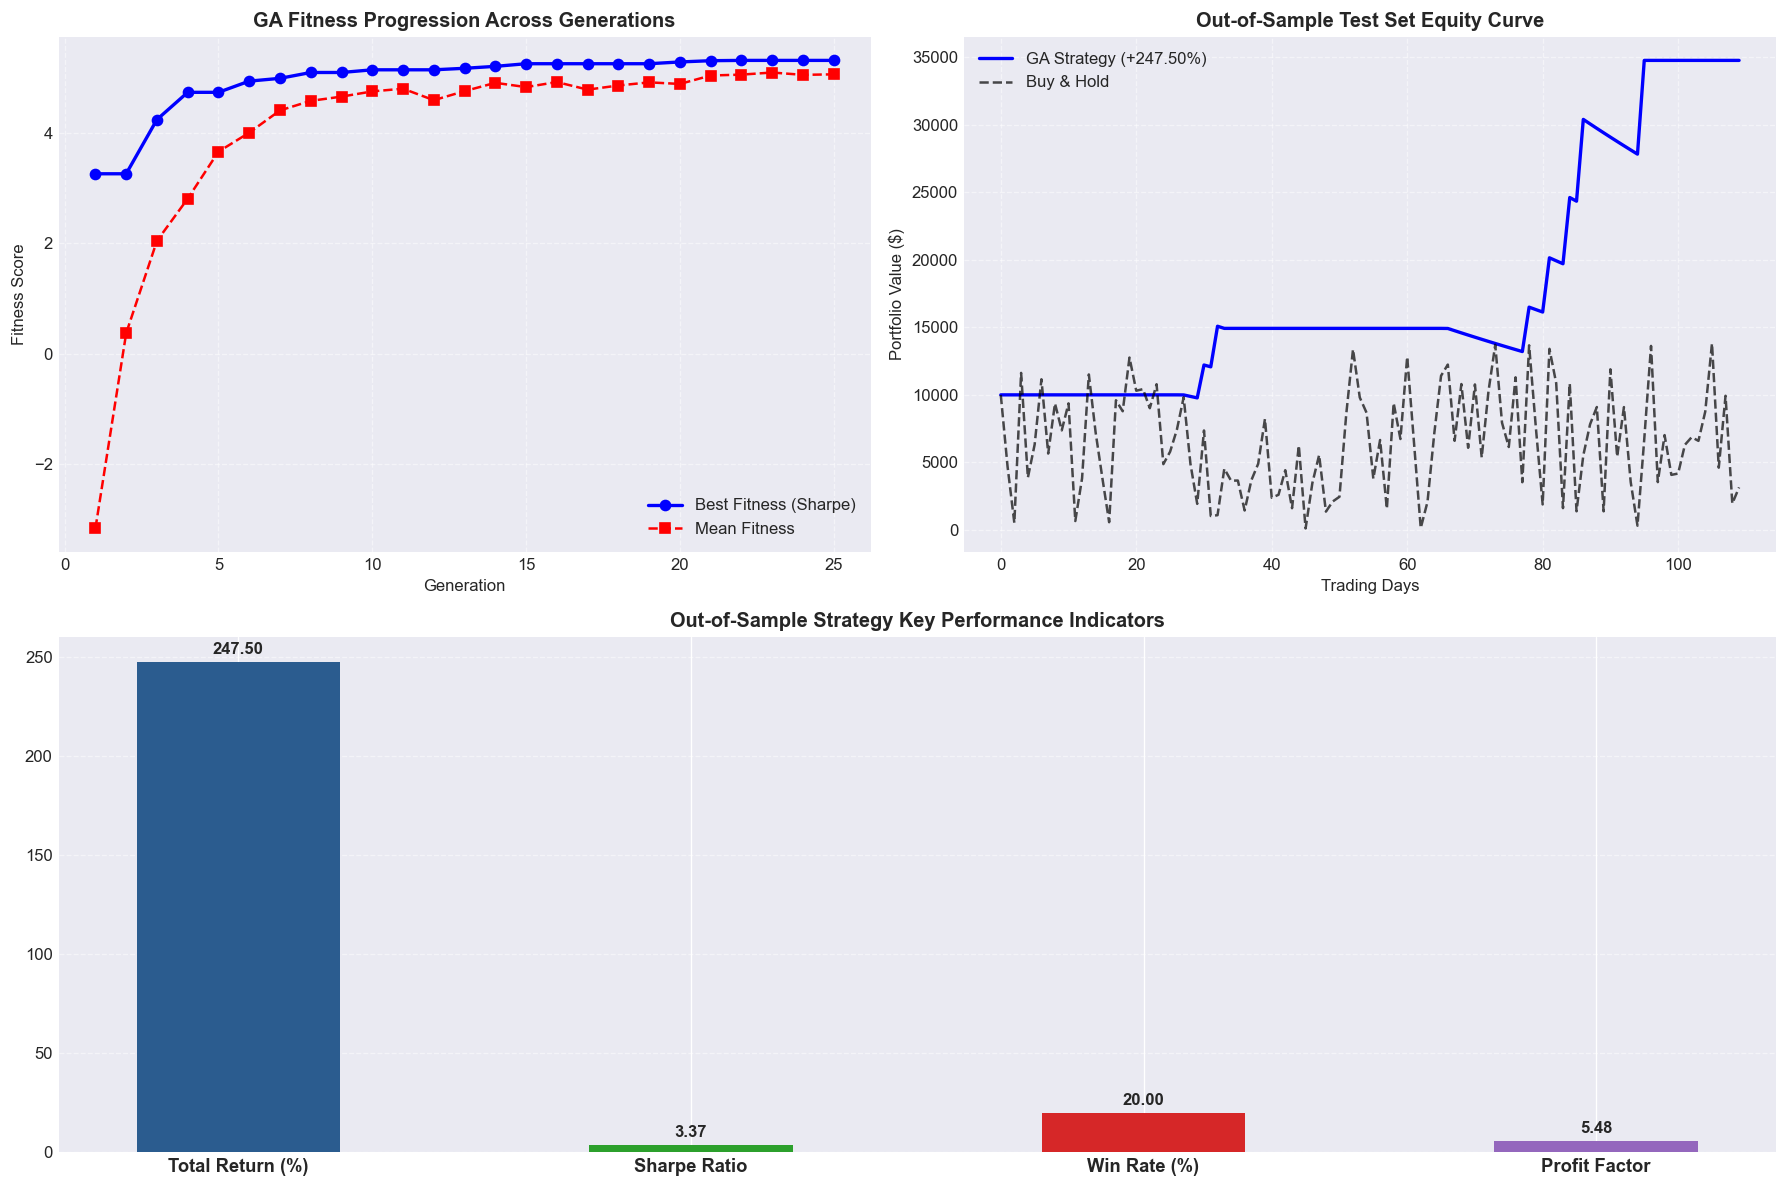

In [7]:
fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(2, 2, 1)
gens = range(1, len(history["best_fitness"]) + 1)
ax1.plot(gens, history["best_fitness"], "b-o", linewidth=2, label="Best Fitness (Sharpe)")
ax1.plot(gens, history["mean_fitness"], "r--s", linewidth=1.5, label="Mean Fitness")
ax1.set_title("GA Fitness Progression Across Generations", fontweight="bold", fontsize=12)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness Score")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(test_results["equity_curve"], "b-", linewidth=2, label=f"GA Strategy ({test_results['total_return_pct']:+.2f}%)")
ax2.plot(test_results["buy_and_hold_equity"], "k--", linewidth=1.5, alpha=0.7, label="Buy & Hold")
ax2.set_title("Out-of-Sample Test Set Equity Curve", fontweight="bold", fontsize=12)
ax2.set_xlabel("Trading Days")
ax2.set_ylabel("Portfolio Value ($)")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

ax3 = fig.add_subplot(2, 1, 2)
metrics = ["Total Return (%)", "Sharpe Ratio", "Win Rate (%)", "Profit Factor"]
strategy_vals = [
    test_results["total_return_pct"],
    test_results["sharpe_ratio"],
    test_results["win_rate_pct"],
    test_results["profit_factor"],
]

x = np.arange(len(metrics))
bars = ax3.bar(x, strategy_vals, color=["#2b5c8f", "#2ca02c", "#d62728", "#9467bd"], width=0.45)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics, fontweight="bold", fontsize=11)
ax3.set_title("Out-of-Sample Strategy Key Performance Indicators", fontweight="bold", fontsize=12)
ax3.grid(True, axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax3.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()
